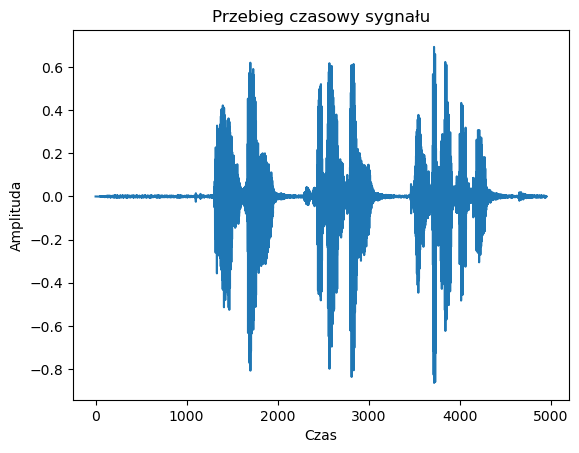

In [14]:
import soundfile as sf
import sounddevice as sd
import matplotlib.pyplot as plt
import numpy as np


filename = 'Audio.wav'  
s, fs = sf.read(filename)


if len(s.shape) > 1:
    s = s[:, 0]

czas = np.arange(len(s)) / fs * 1000  
plt.plot(czas, s)
plt.xlabel("Czas")
plt.ylabel("Amplituda")
plt.title("Przebieg czasowy sygnału")
plt.show()


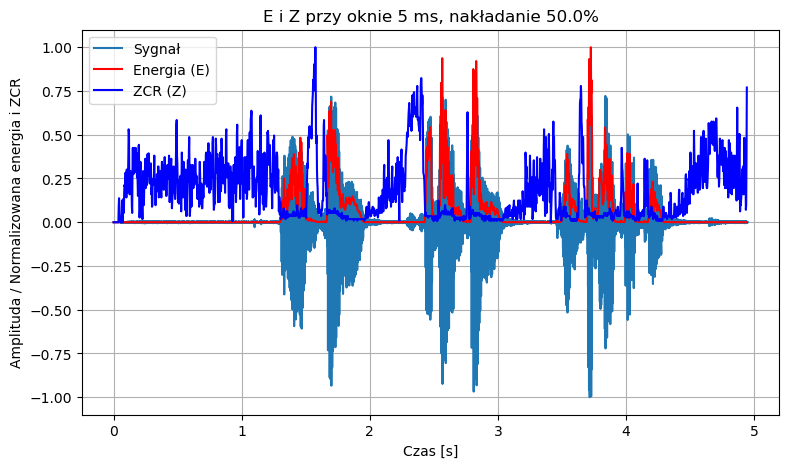

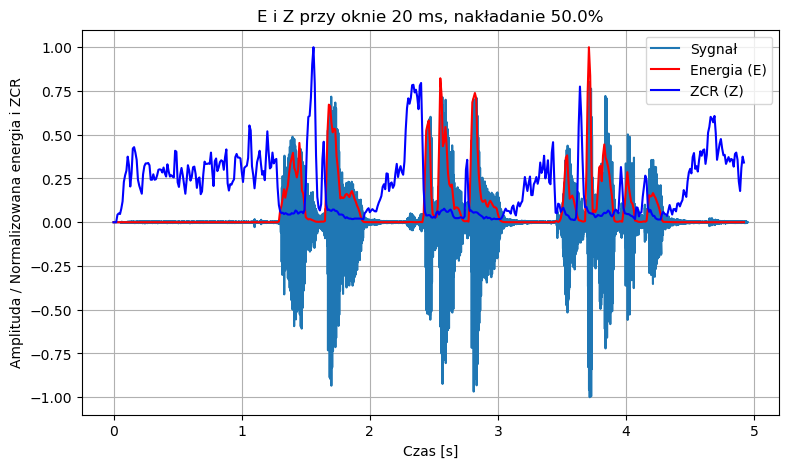

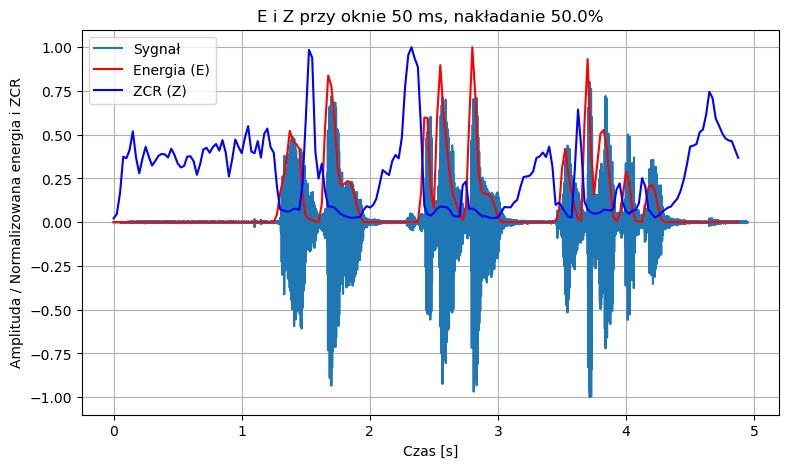

In [15]:
def analyze_signal(signal, fs, window_ms, nakladanie, plot=True):
    rozm_okna = int(window_ms * fs / 1000)
    krok = int(rozm_okna * 0.5)
    
    frames = []
    for start in range(0, len(signal) - rozm_okna + 1, krok):
        frames.append(signal[start:start + rozm_okna])
   
    E = np.array([np.sum(f ** 2) for f in frames])
    Z = np.array([np.sum(np.abs(np.diff(np.sign(f)))) / 2 for f in frames])

    E = E / np.max(E)
    Z = Z / np.max(Z)

    t = np.arange(len(E)) * krok / fs

    if plot:
        plt.figure(figsize=(9, 5))
        czas = np.arange(len(signal)) / fs
        plt.plot(czas, signal, label="Sygnał")
        plt.plot(t, E, 'r', label='Energia (E)')
        plt.plot(t, Z, 'b', label='ZCR (Z)')

        plt.xlabel("Czas [s]")
        plt.ylabel("Amplituda / Normalizowana energia i ZCR")

        plt.title(f"E i Z przy oknie {window_ms} ms, nakładanie {nakladanie*100}%")
        plt.legend()
        plt.grid()
        plt.show()
    else:
        return E, Z, t





s = s / np.max(np.abs(s)) 

for win_ms in [5, 20, 50]:
    analyze_signal(s, fs, window_ms=win_ms, nakladanie=0.5)


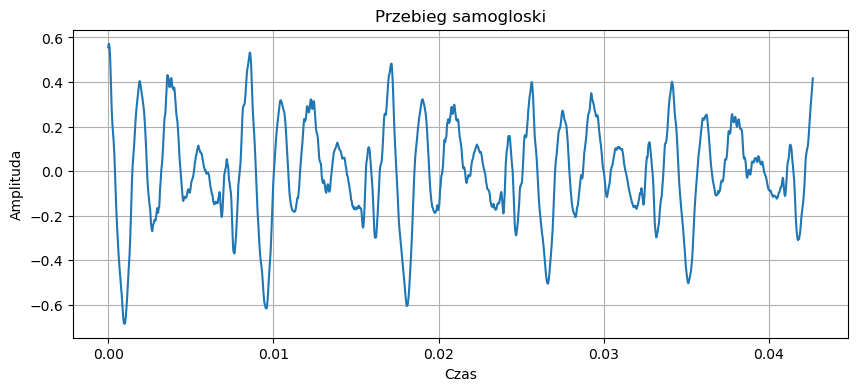

In [16]:

start = 2.6
start_sample = int(start * fs)

frame = s[start_sample:start_sample + 2048]
plt.figure(figsize=(10, 4))
t = np.arange(2048) / fs
plt.plot(t, frame)
plt.xlabel("Czas")
plt.ylabel("Amplituda")
plt.title("Przebieg samogloski")
plt.grid()

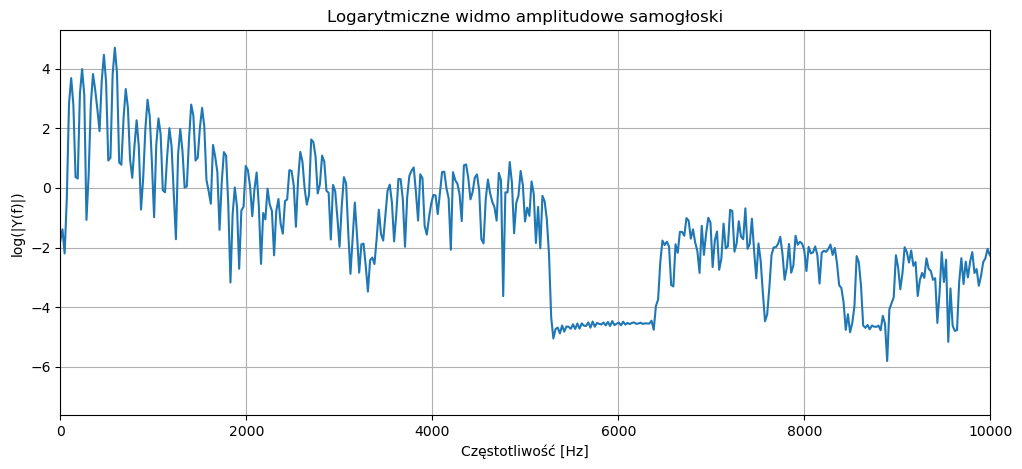

In [17]:
import scipy.fftpack

ham = frame * np.hamming(len(frame))

yf = scipy.fftpack.fft(ham)
magnitude = np.abs(yf[:len(yf)//2]) 
log = np.log(magnitude + 1e-10)  

freqs = np.linspace(0, fs/2, len(log))

plt.figure(figsize=(12, 5))
plt.plot(freqs, log)
plt.title("Logarytmiczne widmo amplitudowe samogłoski")
plt.xlabel("Częstotliwość [Hz]")
plt.ylabel("log(|Y(f)|)")
plt.xlim([0, 10000])
plt.grid()
plt.show()



In [18]:
from scipy.signal import find_peaks


peaks, _ = find_peaks(log)
for p in peaks:
    if freqs[p] > 50:
        f0 = freqs[p]
        print(f"Znaleziony pik: {f0:.2f} Hz")
        break




Znaleziony pik: 117.30 Hz


F0 = 117.30205278592376


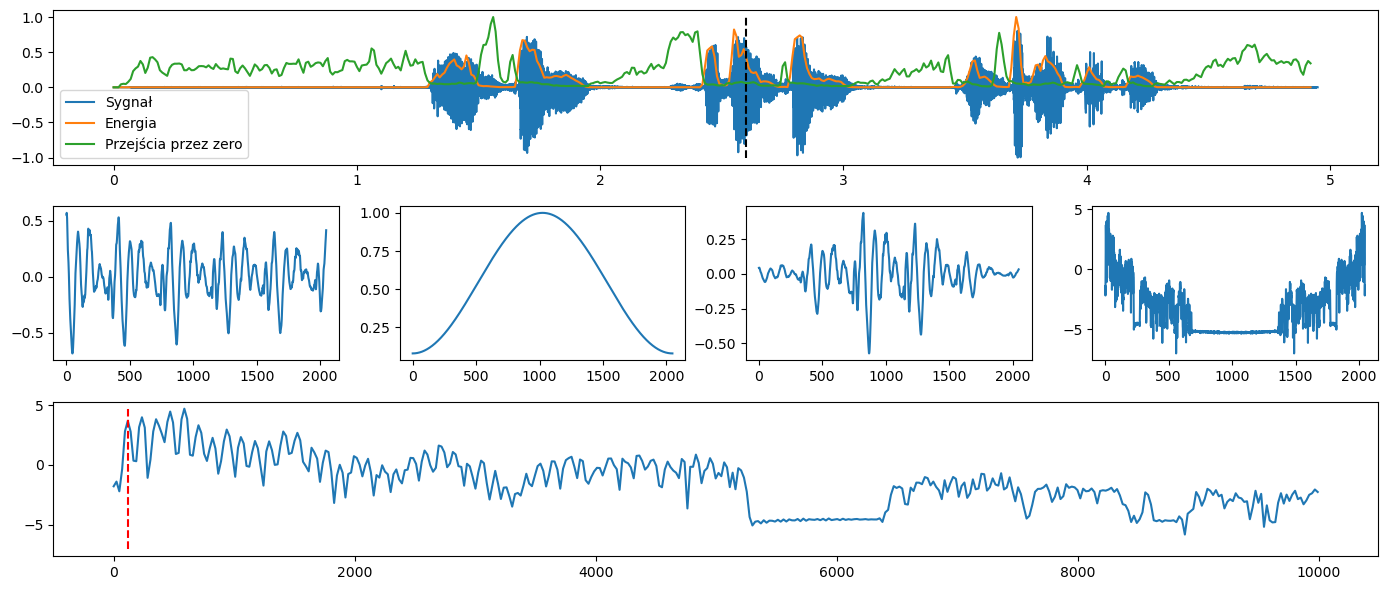

F0 = 117.30205278592376


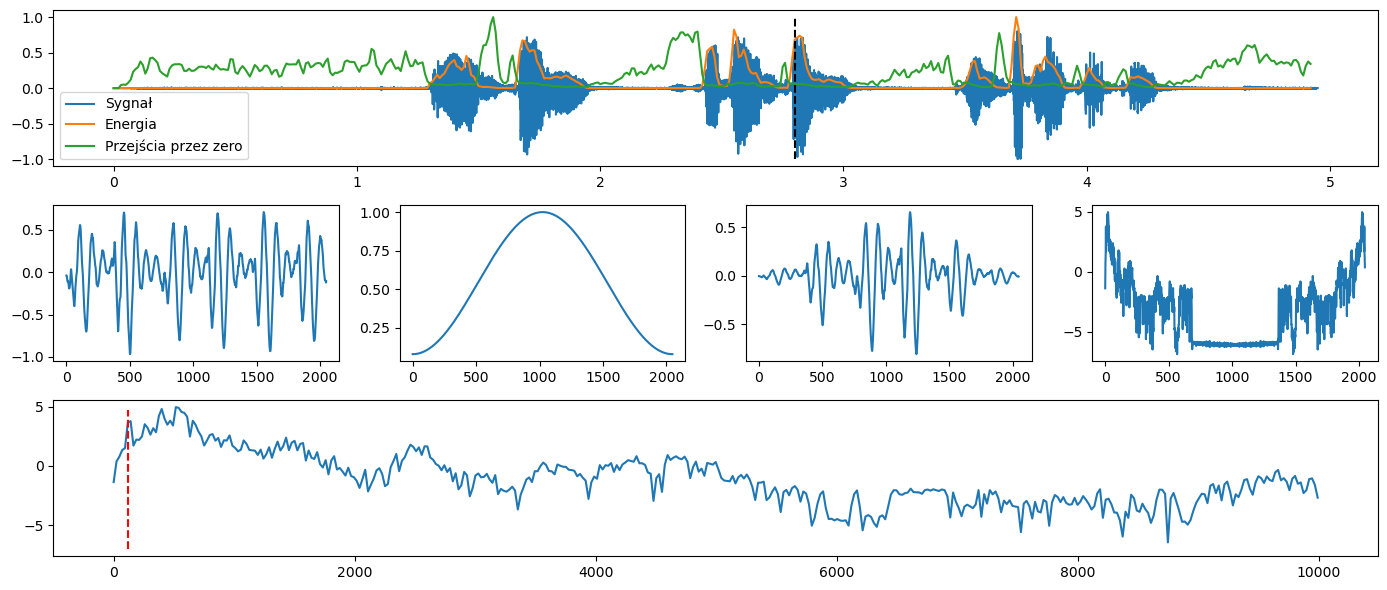

F0 = 117.30205278592376


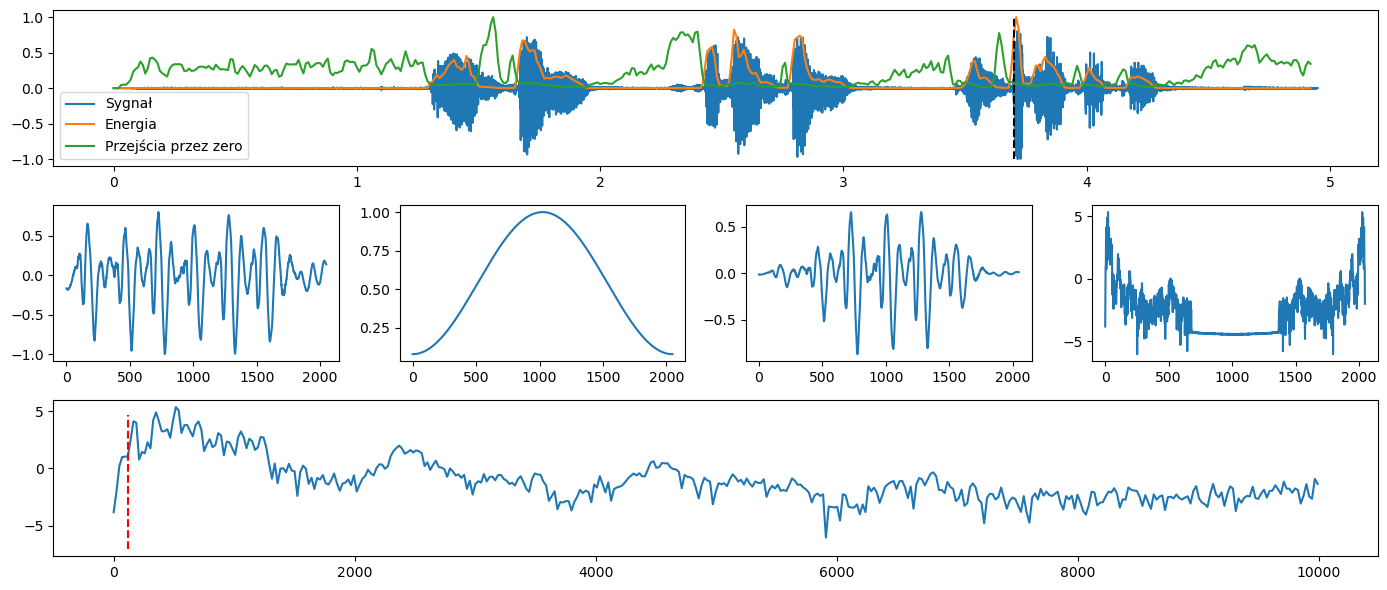

In [19]:
def f(start):    
    samogloska = s[int(start * fs):int(start * fs + 2048)]
    hamming = np.hamming(2048)
    okno = samogloska * hamming


    yf = scipy.fftpack.fft(okno)
    mk = np.log(np.abs(yf))
    fk = np.linspace(0, fs, len(yf))

    E, Z, T_ms = analyze_signal(s, fs, window_ms=20, nakladanie=0.5, plot=False)

    peaks, _ = scipy.signal.find_peaks(mk)
    print("F0 = " + str(f0))

    plt.figure(figsize=(14, 6))

    plt.subplot(3, 1, 1)
    t = np.arange(len(s)) / fs 
    plt.plot(t, s, label="Sygnał")
    plt.plot(T_ms, E, label="Energia")
    plt.plot(T_ms, Z, label="Przejścia przez zero")
    plt.plot([start, start], [-1, 1], "--k")
    plt.legend()

    plt.subplot(3, 4, 5)
    plt.plot(samogloska)

    plt.subplot(3, 4, 6)
    plt.plot(hamming)

    plt.subplot(3, 4, 7)
    plt.plot(okno)

    plt.subplot(3, 4, 8)
    plt.plot(mk)

    plt.subplot(3, 1, 3)
    plt.plot(fk[fk <= 10000], mk[fk <= 10000])
    plt.plot([f0, f0], [min(log), max(log)], '--r')

    plt.tight_layout()
    plt.show()


f(2.6)
f(2.8)
f(3.7)